<a href="https://colab.research.google.com/github/Ip0qI/Codes/blob/main/Prisoner'sDilemma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
"Reconfigure the notebook to simulate the Iterated Prisoner's Dilemma. The simulation will compare existing and newly defined AI and algorithmic strategies, such as 'Always Defect', 'Tit for Tat', 'Human-like', 'Q-Learning', 'Human-like AI', 'Opponent Predictor', 'Always Cooperate', 'Random', 'Sucker', and 'Generous Tit for Tat'. Define game rules, reward functions, and core game logic, then set up and execute multiple experimental runs. Finally, analyze and visualize the overall experiment results from the `all_runs_average_rewards.csv` file to assess the reliability of the strategies, and provide a conclusion."

## 노트북 소개 및 목표

### Subtask:
노트북의 전체적인 목표와 시뮬레이션의 목적(예: '반복 죄수의 딜레마 게임을 통한 AI와 알고리즘들의 신뢰성 확인')을 설명하는 텍스트 셀을 배치합니다.


```markdown
## Iterated Prisoner's Dilemma Simulation

이 노트북은 반복 죄수의 딜레마 게임을 통해 다양한 AI 및 알고리즘 전략들의 신뢰성과 성능을 비교 분석하는 시뮬레이션을 수행합니다. 'Always Defect', 'Tit for Tat', 'Human-like', 'Q-Learning', 'Human-like AI', 'Opponent Predictor', 'Always Cooperate', 'Random', 'Sucker', 'Generous Tit for Tat' 등 여러 전략들을 정의하고, 이들 간의 상호작용을 실험하여 각 전략의 효과를 평가합니다.
```

## 필요 라이브러리 임포트

### Subtask:
numpy, random, matplotlib.pyplot, pandas, os 등 시뮬레이션 및 데이터 처리, 시각화에 필요한 모든 라이브러리를 한곳에 모아 임포트합니다.


**Reasoning**:
The subtask requires importing several libraries for simulation, data processing, and visualization. I will import all the specified libraries in a single code block.



In [71]:
# @title
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## 기본 게임 규칙 및 보상 함수 정의

### Subtask:
죄수의 딜레마 게임의 보상값 (R, T, S, P)을 정의하고, 두 플레이어의 행동에 따른 보상을 계산하는 `get_reward` 함수를 정의합니다.


**Reasoning**:
The subtask requires defining the reward values for the Prisoner's Dilemma and implementing the `get_reward` function based on specific rules. I will define the global reward variables and the function in a code block, using the values already present in the kernel.



In [72]:
# @title
R = 3  # Reward for mutual cooperation
T = 5  # Temptation to defect
S = 0  # Sucker's payoff
P = 1  # Punishment for mutual defection

def get_reward(action1, action2):
    """
    Calculates the rewards for two players based on their actions in the Prisoner's Dilemma.

    Args:
        action1 (int): Player 1's action (0 for Cooperate, 1 for Defect).
        action2 (int): Player 2's action (0 for Cooperate, 1 for Defect).

    Returns:
        tuple: A tuple containing (reward_player1, reward_player2).
    """
    if action1 == 0 and action2 == 0:  # Both Cooperate (C, C)
        return R, R
    elif action1 == 0 and action2 == 1:  # Player 1 Cooperates, Player 2 Defects (C, D)
        return S, T
    elif action1 == 1 and action2 == 0:  # Player 1 Defects, Player 2 Cooperates (D, C)
        return T, S
    elif action1 == 1 and action2 == 1:  # Both Defect (D, D)
        return P, P
    else:
        raise ValueError("Actions must be 0 (Cooperate) or 1 (Defect).")

print(f"Reward values: R={R}, T={T}, S={S}, P={P}")
print("get_reward function defined.")

Reward values: R=3, T=5, S=0, P=1
get_reward function defined.


## 기존 에이전트 전략 정의

### Subtask:
기존 에이전트 전략을 함수 또는 클래스 형태로 정의합니다. 여기에는 `always_defect`, `tit_for_tat`, `human_like`와 같은 함수 형태의 에이전트와 `QAgent`, `HumanLikeAI`, `OpponentPredictorAgent`와 같은 클래스 형태의 에이전트 정의가 포함됩니다.


**Reasoning**:
The subtask requires defining existing agent strategies as functions or classes. I will implement all specified strategies: 'Always Defect', 'Tit for Tat', 'Human-like', 'Q-Learning', 'Human-like AI', 'Opponent Predictor', 'Always Cooperate', 'Random', 'Sucker', and 'Generous Tit for Tat'. Each will have a `choose_action` method (or be a simple function) that takes `history_self` and `history_opponent` as arguments, and `QAgent` will also include an `update` method. I will define these in a single code block to maintain logical grouping and ensure all necessary libraries (`numpy`, `random`) are implicitly available from previous imports.



In [73]:
# @title
import numpy as np # Already imported, but good to have explicit for QAgent
import random # Already imported

# Define action constants for clarity
COOPERATE = 0
DEFECT = 1

# --- Function-based Strategies ---

def always_defect(history_self, history_opponent):
    """Always defects."""
    return DEFECT

def always_cooperate(history_self, history_opponent):
    """Always cooperates."""
    return COOPERATE

def random_strategy(history_self, history_opponent):
    """Chooses action randomly."""
    return random.choice([COOPERATE, DEFECT])

def tit_for_tat(history_self, history_opponent):
    """Cooperates on the first move, then mimics opponent's last move."""
    if not history_opponent: # First round
        return COOPERATE
    return history_opponent[-1]

def generous_tit_for_tat(history_self, history_opponent, forgiveness_rate=0.3):
    """Like Tit for Tat, but sometimes cooperates even if opponent defected."""
    if not history_opponent: # First round
        return COOPERATE
    if history_opponent[-1] == COOPERATE:
        return COOPERATE
    else: # Opponent defected
        if random.random() < forgiveness_rate:
            return COOPERATE # Forgive and cooperate
        else:
            return DEFECT # Retaliate

def sucker_strategy(history_self, history_opponent):
    """Always cooperates, regardless of opponent's actions."""
    return COOPERATE

def human_like(history_self, history_opponent, forgiveness_threshold=0.6, revenge_threshold=0.4, random_factor=0.05):
    """A strategy that tries to act 'human-like' based on recent history with some randomness.
    It tries to forgive if the opponent has a high cooperation rate, but retaliates if consistently defected upon.
    """
    if not history_opponent: # First round
        return COOPERATE

    # Introduce some randomness
    if random.random() < random_factor:
        return random.choice([COOPERATE, DEFECT])

    # Calculate opponent's cooperation rate in recent history (e.g., last 5 rounds)
    recent_history_len = min(len(history_opponent), 5)
    if recent_history_len == 0:
        return COOPERATE

    recent_opponent_history = history_opponent[-recent_history_len:]
    cooperation_count = recent_opponent_history.count(COOPERATE)
    defection_count = recent_opponent_history.count(DEFECT)

    cooperation_rate = cooperation_count / recent_history_len
    defection_rate = defection_count / recent_history_len

    if history_opponent[-1] == COOPERATE: # If opponent cooperated last, tend to cooperate
        return COOPERATE
    elif history_opponent[-1] == DEFECT: # If opponent defected last
        if cooperation_rate > forgiveness_threshold: # Opponent mostly cooperates despite last defection
            return COOPERATE # Forgive
        elif defection_rate > revenge_threshold: # Opponent often defects
            return DEFECT # Retaliate
        else:
            return DEFECT # Default retaliation
    return COOPERATE # Default to cooperate if no strong pattern

# --- Class-based Strategies ---

class QAgent:
    """Q-Learning agent. State is opponent's last move. Actions are Cooperate/Defect.
    Q-table: [opponent_last_move][my_action]
    """
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        # Q-table: rows for opponent's last action (COOPERATE=0, DEFECT=1), columns for agent's action (COOPERATE=0, DEFECT=1)
        self.q_table = np.zeros((2, 2))
        self.last_state = None
        self.last_action = None

    def get_state(self, history_opponent):
        """Determines the current state based on opponent's last move."""
        if not history_opponent: # Initial state, no history. Arbitrarily choose 'cooperated last'
            return COOPERATE # Assume initial cooperation from opponent for state definition
        return history_opponent[-1]

    def choose_action(self, history_self, history_opponent):
        state = self.get_state(history_opponent)
        self.last_state = state

        if random.random() < self.epsilon: # Explore
            action = random.choice([COOPERATE, DEFECT])
        else: # Exploit
            action = np.argmax(self.q_table[state, :])

        self.last_action = action
        return action

    def update_q_table(self, reward_self, next_history_opponent):
        """Update the Q-table after an action is taken and reward received."""
        if self.last_state is None or self.last_action is None:
            return # Not enough history to update

        old_q_value = self.q_table[self.last_state, self.last_action]
        next_state = self.get_state(next_history_opponent)
        max_future_q = np.max(self.q_table[next_state, :])

        new_q_value = old_q_value + self.alpha * (reward_self + self.gamma * max_future_q - old_q_value)
        self.q_table[self.last_state, self.last_action] = new_q_value


class HumanLikeAI:
    """Combines aspects of Tit For Tat, forgiveness, and some defection tendency.
    It's more forgiving than strict TFT but can get aggressive if repeatedly exploited.
    """
    def __init__(self):
        self.defection_threshold = 3 # Number of consecutive defections to trigger retaliation
        self.forgiveness_counter = 0 # How many times it forgives
        self.forgiveness_limit = 2 # Max times to forgive a single defection streak

    def choose_action(self, history_self, history_opponent):
        if not history_opponent:
            return COOPERATE # Start with cooperation

        last_opponent_move = history_opponent[-1]

        if last_opponent_move == COOPERATE:
            self.forgiveness_counter = 0 # Reset forgiveness if opponent cooperates
            return COOPERATE
        else: # Opponent defected
            # Check for consecutive defections from opponent
            consecutive_defections = 0
            for move in reversed(history_opponent):
                if move == DEFECT:
                    consecutive_defections += 1
                else:
                    break

            if consecutive_defections >= self.defection_threshold: # If opponent is consistently defecting
                return DEFECT # Retaliate
            elif self.forgiveness_counter < self.forgiveness_limit: # Forgive a few times if not a streak
                self.forgiveness_counter += 1
                return COOPERATE
            else: # Max forgiveness reached for a single defection
                return DEFECT

class OpponentPredictorAgent:
    """Analyzes opponent's history to predict their next move and responds 'optimally' (cooperate for mutual gain, defect to avoid loss)."""
    def __init__(self, prediction_horizon=5):
        self.prediction_horizon = prediction_horizon

    def predict_opponent_action(self, history_opponent):
        if not history_opponent or len(history_opponent) < 2: # Not enough data for prediction
            return COOPERATE # Default prediction

        recent_history = history_opponent[-self.prediction_horizon:]

        coop_count = recent_history.count(COOPERATE)
        def_count = recent_history.count(DEFECT)

        if coop_count > def_count: # More cooperation recently
            return COOPERATE
        elif def_count > coop_count: # More defection recently
            return DEFECT
        else: # Even split or very short history
            return history_opponent[-1] # Predict based on last move

    def choose_action(self, history_self, history_opponent):
        predicted_opponent_action = self.predict_opponent_action(history_opponent)

        # Respond to the prediction
        if predicted_opponent_action == COOPERATE:
            # If opponent is predicted to cooperate, cooperate for mutual R (IPD specific optimal)
            return COOPERATE
        else: # Predicted opponent action is DEFECT
            # If opponent is predicted to defect, defect to avoid S and get P
            return DEFECT

print("All agent strategies (functions and classes) have been defined.")

All agent strategies (functions and classes) have been defined.


<!-- ## 새로운 에이전트 전략 정의

### Subtask:
새로 추가된 에이전트 전략 함수를 정의하는 코드를 배치합니다. -->

## 에이전트 전략 상세 설명

### Subtask:
각 에이전트 전략(예: Always Defect, Tit for Tat, Human-like 등)의 특징과 선택 기준을 자세히 설명하는 텍스트 셀을 배치하여 각 에이전트의 역할을 명확히 이해할 수 있도록 합니다.


```markdown
## 에이전트 전략 상세 설명

각 에이전트 전략의 특징과 선택 기준을 자세히 설명하여 각 에이전트의 역할을 명확히 이해할 수 있도록 합니다.

*   **Always Defect (항상 배신)**: 항상 상대방을 배신합니다. 상대방의 과거 행동과 관계없이 자신의 이득을 최대화하기 위해 배신을 선택합니다.
*   **Always Cooperate (항상 협력)**: 항상 상대방과 협력합니다. 어떤 상황에서도 협력을 유지하며, 장기적인 관계에서 상호 이득을 추구하는 전략입니다.
*   **Random (무작위)**: 무작위로 협력하거나 배신합니다. 상대방의 행동이나 게임의 맥락과 상관없이 50% 확률로 협력 또는 배신을 선택합니다.
*   **Tit for Tat (눈에는 눈 이에는 이)**: 첫 턴에는 협력하고, 이후에는 상대방의 이전 턴 행동을 그대로 따라 합니다. 단순하지만 강력한 전략으로, 협력에는 협력으로, 배신에는 배신으로 응수합니다.
*   **Generous Tit for Tat (관대한 눈에는 눈 이에는 이)**: Tit for Tat과 유사하지만, 상대방이 배신했을 때 일정 확률로 용서하고 협력합니다. 상대방의 실수를 한두 번 용서하여 관계 개선의 기회를 제공합니다.
*   **Sucker (호구)**: 항상 협력하며, 상대방의 행동에 영향을 받지 않습니다. 상대방이 어떻게 나오든 일방적으로 협력적인 태도를 유지합니다.
*   **Human-like (인간적인)**: 과거 이력을 바탕으로 상대방의 협력률을 평가하여 용서하거나 보복하며, 약간의 무작위성을 가집니다. 상대방의 장기적인 행동 패턴에 따라 전략을 조절합니다.
*   **Q-Learning (Q-학습)**: 강화 학습을 사용하여 상대방의 마지막 행동을 상태로 보고 최적의 행동을 학습합니다. 시행착오를 통해 보상을 최대화하는 행동 정책을 찾아냅니다.
*   **HumanLikeAI (인간적인 AI)**: Tit for Tat, 용서, 그리고 반복적인 배신에 대한 보복 경향을 결합한 전략입니다. 상대방의 연속적인 배신에 대해 더 강력하게 대응하는 경향이 있습니다.
*   **Opponent Predictor (상대방 예측기)**: 상대방의 최근 행동 이력을 분석하여 다음 행동을 예측하고, 이에 최적으로 대응합니다. 예측을 기반으로 자신의 행동을 결정하여 이득을 극대화하려 합니다.
```


<!-- ## 에이전트 전략 상세 설명

각 에이전트 전략의 특징과 선택 기준을 자세히 설명하여 각 에이전트의 역할을 명확히 이해할 수 있도록 합니다.

*   **Always Defect (항상 배신)**: 항상 상대방을 배신합니다. 상대방의 과거 행동과 관계없이 자신의 이득을 최대화하기 위해 배신을 선택합니다.
*   **Always Cooperate (항상 협력)**: 항상 상대방과 협력합니다. 어떤 상황에서도 협력을 유지하며, 장기적인 관계에서 상호 이득을 추구하는 전략입니다.
*   **Random (무작위)**: 무작위로 협력하거나 배신합니다. 상대방의 행동이나 게임의 맥락과 상관없이 50% 확률로 협력 또는 배신을 선택합니다.
*   **Tit for Tat (눈에는 눈 이에는 이)**: 첫 턴에는 협력하고, 이후에는 상대방의 이전 턴 행동을 그대로 따라 합니다. 단순하지만 강력한 전략으로, 협력에는 협력으로, 배신에는 배신으로 응수합니다.
*   **Generous Tit for Tat (관대한 눈에는 눈 이에는 이)**: Tit for Tat과 유사하지만, 상대방이 배신했을 때 일정 확률로 용서하고 협력합니다. 상대방의 실수를 한두 번 용서하여 관계 개선의 기회를 제공합니다.
*   **Sucker (호구)**: 항상 협력하며, 상대방의 행동에 영향을 받지 않습니다. 상대방이 어떻게 나오든 일방적으로 협력적인 태도를 유지합니다.
*   **Human-like (인간적인)**: 과거 이력을 바탕으로 상대방의 협력률을 평가하여 용서하거나 보복하며, 약간의 무작위성을 가집니다. 상대방의 장기적인 행동 패턴에 따라 전략을 조절합니다.
*   **Q-Learning (Q-학습)**: 강화 학습을 사용하여 상대방의 마지막 행동을 상태로 보고 최적의 행동을 학습합니다. 시행착오를 통해 보상을 최대화하는 행동 정책을 찾아냅니다.
*   **HumanLikeAI (인간적인 AI)**: Tit for Tat, 용서, 그리고 반복적인 배신에 대한 보복 경향을 결합한 전략입니다. 상대방의 연속적인 배신에 대해 더 강력하게 대응하는 경향이 있습니다.
*   **Opponent Predictor (상대방 예측기)**: 상대방의 최근 행동 이력을 분석하여 다음 행동을 예측하고, 이에 최적으로 대응합니다. 예측을 기반으로 자신의 행동을 결정하여 이득을 극대화하려 합니다. -->

<!-- ## 에이전트 전략 상세 설명

각 에이전트 전략의 특징과 선택 기준을 자세히 설명하여 각 에이전트의 역할을 명확히 이해할 수 있도록 합니다.

*   **Always Defect (항상 배신)**: 항상 상대방을 배신합니다. 상대방의 과거 행동과 관계없이 자신의 이득을 최대화하기 위해 배신을 선택합니다.
*   **Always Cooperate (항상 협력)**: 항상 상대방과 협력합니다. 어떤 상황에서도 협력을 유지하며, 장기적인 관계에서 상호 이득을 추구하는 전략입니다.
*   **Random (무작위)**: 무작위로 협력하거나 배신합니다. 상대방의 행동이나 게임의 맥락과 상관없이 50% 확률로 협력 또는 배신을 선택합니다.
*   **Tit for Tat (눈에는 눈 이에는 이)**: 첫 턴에는 협력하고, 이후에는 상대방의 이전 턴 행동을 그대로 따라 합니다. 단순하지만 강력한 전략으로, 협력에는 협력으로, 배신에는 배신으로 응수합니다.
*   **Generous Tit for Tat (관대한 눈에는 눈 이에는 이)**: Tit for Tat과 유사하지만, 상대방이 배신했을 때 일정 확률로 용서하고 협력합니다. 상대방의 실수를 한두 번 용서하여 관계 개선의 기회를 제공합니다.
*   **Sucker (호구)**: 항상 협력하며, 상대방의 행동에 영향을 받지 않습니다. 상대방이 어떻게 나오든 일방적으로 협력적인 태도를 유지합니다.
*   **Human-like (인간적인)**: 과거 이력을 바탕으로 상대방의 협력률을 평가하여 용서하거나 보복하며, 약간의 무작위성을 가집니다. 상대방의 장기적인 행동 패턴에 따라 전략을 조절합니다.
*   **Q-Learning (Q-학습)**: 강화 학습을 사용하여 상대방의 마지막 행동을 상태로 보고 최적의 행동을 학습합니다. 시행착오를 통해 보상을 최대화하는 행동 정책을 찾아냅니다.
*   **HumanLikeAI (인간적인 AI)**: Tit for Tat, 용서, 그리고 반복적인 배신에 대한 보복 경향을 결합한 전략입니다. 상대방의 연속적인 배신에 대해 더 강력하게 대응하는 경향이 있습니다.
*   **Opponent Predictor (상대방 예측기)**: 상대방의 최근 행동 이력을 분석하여 다음 행동을 예측하고, 이에 최적으로 대응합니다. 예측을 기반으로 자신의 행동을 결정하여 이득을 극대화하려 합니다. -->

<!-- ## 에이전트 전략 상세 설명

각 에이전트 전략의 특징과 선택 기준을 자세히 설명하여 각 에이전트의 역할을 명확히 이해할 수 있도록 합니다.

*   **Always Defect (항상 배신)**: 항상 상대방을 배신합니다. 상대방의 과거 행동과 관계없이 자신의 이득을 최대화하기 위해 배신을 선택합니다.
*   **Always Cooperate (항상 협력)**: 항상 상대방과 협력합니다. 어떤 상황에서도 협력을 유지하며, 장기적인 관계에서 상호 이득을 추구하는 전략입니다.
*   **Random (무작위)**: 무작위로 협력하거나 배신합니다. 상대방의 행동이나 게임의 맥락과 상관없이 50% 확률로 협력 또는 배신을 선택합니다.
*   **Tit for Tat (눈에는 눈 이에는 이)**: 첫 턴에는 협력하고, 이후에는 상대방의 이전 턴 행동을 그대로 따라 합니다. 단순하지만 강력한 전략으로, 협력에는 협력으로, 배신에는 배신으로 응수합니다.
*   **Generous Tit for Tat (관대한 눈에는 눈 이에는 이)**: Tit for Tat과 유사하지만, 상대방이 배신했을 때 일정 확률로 용서하고 협력합니다. 상대방의 실수를 한두 번 용서하여 관계 개선의 기회를 제공합니다.
*   **Sucker (호구)**: 항상 협력하며, 상대방의 행동에 영향을 받지 않습니다. 상대방이 어떻게 나오든 일방적으로 협력적인 태도를 유지합니다.
*   **Human-like (인간적인)**: 과거 이력을 바탕으로 상대방의 협력률을 평가하여 용서하거나 보복하며, 약간의 무작위성을 가집니다. 상대방의 장기적인 행동 패턴에 따라 전략을 조절합니다.
*   **Q-Learning (Q-학습)**: 강화 학습을 사용하여 상대방의 마지막 행동을 상태로 보고 최적의 행동을 학습합니다. 시행착오를 통해 보상을 최대화하는 행동 정책을 찾아냅니다.
*   **HumanLikeAI (인간적인 AI)**: Tit for Tat, 용서, 그리고 반복적인 배신에 대한 보복 경향을 결합한 전략입니다. 상대방의 연속적인 배신에 대해 더 강력하게 대응하는 경향이 있습니다.
*   **Opponent Predictor (상대방 예측기)**: 상대방의 최근 행동 이력을 분석하여 다음 행동을 예측하고, 이에 최적으로 대응합니다. 예측을 기반으로 자신의 행동을 결정하여 이득을 극대화하려 합니다. -->

<!-- ## 에이전트 전략 상세 설명

각 에이전트 전략의 특징과 선택 기준을 자세히 설명하여 각 에이전트의 역할을 명확히 이해할 수 있도록 합니다.

*   **Always Defect (항상 배신)**: 항상 상대방을 배신합니다. 상대방의 과거 행동과 관계없이 자신의 이득을 최대화하기 위해 배신을 선택합니다.
*   **Always Cooperate (항상 협력)**: 항상 상대방과 협력합니다. 어떤 상황에서도 협력을 유지하며, 장기적인 관계에서 상호 이득을 추구하는 전략입니다.
*   **Random (무작위)**: 무작위로 협력하거나 배신합니다. 상대방의 행동이나 게임의 맥락과 상관없이 50% 확률로 협력 또는 배신을 선택합니다.
*   **Tit for Tat (눈에는 눈 이에는 이)**: 첫 턴에는 협력하고, 이후에는 상대방의 이전 턴 행동을 그대로 따라 합니다. 단순하지만 강력한 전략으로, 협력에는 협력으로, 배신에는 배신으로 응수합니다.
*   **Generous Tit for Tat (관대한 눈에는 눈 이에는 이)**: Tit for Tat과 유사하지만, 상대방이 배신했을 때 일정 확률로 용서하고 협력합니다. 상대방의 실수를 한두 번 용서하여 관계 개선의 기회를 제공합니다.
*   **Sucker (호구)**: 항상 협력하며, 상대방의 행동에 영향을 받지 않습니다. 상대방이 어떻게 나오든 일방적으로 협력적인 태도를 유지합니다.
*   **Human-like (인간적인)**: 과거 이력을 바탕으로 상대방의 협력률을 평가하여 용서하거나 보복하며, 약간의 무작위성을 가집니다. 상대방의 장기적인 행동 패턴에 따라 전략을 조절합니다.
*   **Q-Learning (Q-학습)**: 강화 학습을 사용하여 상대방의 마지막 행동을 상태로 보고 최적의 행동을 학습합니다. 시행착오를 통해 보상을 최대화하는 행동 정책을 찾아냅니다.
*   **HumanLikeAI (인간적인 AI)**: Tit for Tat, 용서, 그리고 반복적인 배신에 대한 보복 경향을 결합한 전략입니다. 상대방의 연속적인 배신에 대해 더 강력하게 대응하는 경향이 있습니다.
*   **Opponent Predictor (상대방 예측기)**: 상대방의 최근 행동 이력을 분석하여 다음 행동을 예측하고, 이에 최적으로 대응합니다. 예측을 기반으로 자신의 행동을 결정하여 이득을 극대화하려 합니다. -->

## 게임 플레이 핵심 함수 정의

### Subtask:
두 에이전트가 주어진 라운드 동안 게임을 플레이하고 각 에이전트의 누적 보상과 협력률을 반환하는 `play_game` 함수를 정의합니다.


**Reasoning**:
The subtask requires defining the `play_game` function, which simulates the Iterated Prisoner's Dilemma between two agents over a given number of rounds, calculating their total rewards and cooperation rates. The function needs to handle both function-based and class-based agents, update histories, and specifically update Q-tables for Q-learning agents.



In [74]:
# @title
def play_game(agent1, agent2, num_rounds):
    """
    Simulates an Iterated Prisoner's Dilemma game between two agents.

    Args:
        agent1: The first agent (can be a function or an object with a choose_action method).
        agent2: The second agent (can be a function or an object with a choose_action method).
        num_rounds (int): The total number of rounds to play.

    Returns:
        tuple: (total_reward1, total_reward2, cooperation_rate1, cooperation_rate2)
    """
    total_reward1 = 0
    total_reward2 = 0
    history1 = []
    history2 = []
    cooperation_count1 = 0
    cooperation_count2 = 0

    for _ in range(num_rounds):
        # Determine action for agent 1
        if hasattr(agent1, 'choose_action'):
            action1 = agent1.choose_action(history1, history2)
        else: # Assume it's a function-based strategy
            action1 = agent1(history1, history2)

        # Determine action for agent 2
        if hasattr(agent2, 'choose_action'):
            action2 = agent2.choose_action(history2, history1)
        else: # Assume it's a function-based strategy
            action2 = agent2(history2, history1)

        # Get rewards based on actions
        reward1, reward2 = get_reward(action1, action2)

        # Update total rewards
        total_reward1 += reward1
        total_reward2 += reward2

        # Record actions in history
        history1.append(action1)
        history2.append(action2)

        # Update cooperation counts
        if action1 == COOPERATE:
            cooperation_count1 += 1
        if action2 == COOPERATE:
            cooperation_count2 += 1

        # Update Q-table for Q-learning agents
        if isinstance(agent1, QAgent):
            agent1.update_q_table(reward1, history2)
        if isinstance(agent2, QAgent):
            agent2.update_q_table(reward2, history1)

    cooperation_rate1 = cooperation_count1 / num_rounds if num_rounds > 0 else 0
    cooperation_rate2 = cooperation_count2 / num_rounds if num_rounds > 0 else 0

    return total_reward1, total_reward2, cooperation_rate1, cooperation_rate2

print("play_game function defined.")

play_game function defined.


## 에이전트 레지스트리 및 실험 실행 함수 정의

### Subtask:
실험에 참여할 에이전트들을 등록하는 `AGENT_REGISTRY`를 초기화하고, 등록된 에이전트 쌍별로 게임을 실행하여 보상 및 협력률을 계산하는 `run_experiment` 함수를 정의합니다.


**Reasoning**:
The subtask requires defining the `AGENT_REGISTRY` with all agent strategies and then implementing the `run_experiment` function to simulate games between all agent pairs, collect rewards, and cooperation rates. This code block will initialize the registry and define the simulation logic.



In [75]:
# @title
AGENT_REGISTRY = [
    ('Always Defect', lambda: always_defect),
    ('Always Cooperate', lambda: always_cooperate),
    ('Random', lambda: random_strategy),
    ('Tit for Tat', lambda: tit_for_tat),
    ('Generous Tit for Tat', lambda: generous_tit_for_tat),
    ('Sucker', lambda: sucker_strategy),
    ('Human-like', lambda: human_like),
    ('Q-Learning', lambda: QAgent(alpha=0.1, gamma=0.9, epsilon=0.1)), # QAgent requires instantiation
    ('Human-like AI', lambda: HumanLikeAI()), # HumanLikeAI requires instantiation
    ('Opponent Predictor', lambda: OpponentPredictorAgent()), # OpponentPredictorAgent requires instantiation
]

def run_experiment(num_rounds_per_game=100, num_runs_per_pair=10):
    """
    Runs experiments by pitting every agent against every other agent (and itself).

    Args:
        num_rounds_per_game (int): Number of rounds for each individual game.
        num_runs_per_pair (int): Number of times to repeat the game for each pair to average results.

    Returns:
        tuple: (reward_matrix_df, cooperation_matrix_df)
            reward_matrix_df (pd.DataFrame): Average rewards for each agent pair.
            cooperation_matrix_df (pd.DataFrame): Average cooperation rates for each agent pair.
    """
    num_agents = len(AGENT_REGISTRY)
    agent_names = [name for name, _ in AGENT_REGISTRY]

    reward_matrix = np.zeros((num_agents, num_agents))
    cooperation_matrix = np.zeros((num_agents, num_agents))

    print(f"Starting experiment with {num_agents} agents, {num_rounds_per_game} rounds per game, {num_runs_per_pair} runs per pair...")

    for i, (agent1_name, agent1_factory) in enumerate(AGENT_REGISTRY):
        for j, (agent2_name, agent2_factory) in enumerate(AGENT_REGISTRY):
            avg_rewards1 = []
            avg_rewards2 = []
            avg_cooperation1 = []
            avg_cooperation2 = []

            for _ in range(num_runs_per_pair):
                # Instantiate agents for each run to reset their internal states
                agent1_instance = agent1_factory()
                agent2_instance = agent2_factory()

                r1, r2, c1, c2 = play_game(agent1_instance, agent2_instance, num_rounds_per_game)

                avg_rewards1.append(r1)
                avg_rewards2.append(r2)
                avg_cooperation1.append(c1)
                avg_cooperation2.append(c2)

            # Store the average rewards/cooperation for agent1 playing against agent2
            # We store agent1's average reward when playing against agent2
            reward_matrix[i, j] = np.mean(avg_rewards1)
            cooperation_matrix[i, j] = np.mean(avg_cooperation1)

    # Convert to DataFrame for better readability and indexing
    reward_matrix_df = pd.DataFrame(reward_matrix, index=agent_names, columns=agent_names)
    cooperation_matrix_df = pd.DataFrame(cooperation_matrix, index=agent_names, columns=agent_names)

    print("Experiment completed.")
    return reward_matrix_df, cooperation_matrix_df

print("AGENT_REGISTRY and run_experiment function defined.")

AGENT_REGISTRY and run_experiment function defined.


# Task
The next step is to initialize the experiment results folder and set global parameters for the simulation.

## 실험 실행 폴더 초기화 및 파라미터 설정

### Subtask:
다중 실험을 위해 `experiment_results` 폴더를 초기화하고, 각 게임의 라운드 수(`num_rounds_per_game`), 각 쌍의 반복 횟수(`num_runs_per_pair`), 그리고 전체 실험 반복 횟수(`num_experiments`) 등 주요 실험 파라미터를 정의합니다.

## 실험 실행 폴더 초기화 및 파라미터 설정

### Subtask:
다중 실험을 위해 `experiment_results` 폴더를 초기화하고, 각 게임의 라운드 수(`num_rounds_per_game`), 각 쌍의 반복 횟수(`num_runs_per_pair`), 그리고 전체 실험 반복 횟수(`num_experiments`) 등 주요 실험 파라미터를 정의합니다.


**Reasoning**:
I will define the experiment results folder path, create the directory if it doesn't exist using `os.makedirs`, and then define the key experiment parameters as requested in the instructions.



In [80]:
# @title 시행 횟수 입력
import os

# 1. Define the path for the experiment results folder
EXPERIMENT_RESULTS_DIR = 'experiment_results'

# 2. Create the experiment_results folder if it doesn't exist
os.makedirs(EXPERIMENT_RESULTS_DIR, exist_ok=True)
print(f"Created directory: {EXPERIMENT_RESULTS_DIR}")

# 3. Define key experiment parameters
num_rounds_per_game = 100  # Number of rounds for each individual game between two agents
num_runs_per_pair = 10     # Number of times to repeat the game for each pair to average results
num_experiments = 10 # @param {type:"integer"} # Number of overall experiments (to run the entire setup multiple times)

print(f"Experiment parameters set:\n  Rounds per game: {num_rounds_per_game}\n  Runs per pair: {num_runs_per_pair}\n  Total experiments: {num_experiments}")

Created directory: experiment_results
Experiment parameters set:
  Rounds per game: 100
  Runs per pair: 10
  Total experiments: 3


## 다중 실험 실행 및 결과 저장 함수 정의

### Subtask:
전체 실험을 여러 번 반복 실행하고, 각 실행의 결과를 `experiment_results/(n)Times` 폴더에 `average_rewards.csv`로 저장하며, 모든 실행의 결과를 통합하여 `all_runs_average_rewards.csv` 파일에 누적 기록하는 함수(`run_multiple_experiments_and_save_results`)를 정의합니다. 이 함수는 기존 `run_experiment` 함수를 활용합니다.


**Reasoning**:
I need to define a Python function `run_multiple_experiments_and_save_results` that orchestrates multiple experimental runs, saves individual experiment results, and aggregates overall average rewards into a single CSV file, leveraging previously defined functions and global parameters.



In [77]:
# @title
import os
import pandas as pd
import numpy as np

def run_multiple_experiments_and_save_results(num_experiments, num_rounds_per_game, num_runs_per_pair):
    """
    Runs multiple overall experiments, saves individual experiment results, and consolidates
    average rewards across all runs.

    Args:
        num_experiments (int): The total number of times to repeat the entire experiment setup.
        num_rounds_per_game (int): Number of rounds for each individual game between two agents.
        num_runs_per_pair (int): Number of times to repeat the game for each pair to average results.
    """
    all_runs_average_rewards_data = [] # List to collect data for all_runs_average_rewards_df

    print(f"Running {num_experiments} overall experiments...")

    for i in range(num_experiments):
        current_experiment_num = i + 1
        experiment_sub_dir = os.path.join(EXPERIMENT_RESULTS_DIR, f"{current_experiment_num}Times")
        os.makedirs(experiment_sub_dir, exist_ok=True)
        print(f"\n--- Running Experiment {current_experiment_num}/{num_experiments} ---")
        print(f"Saving results to: {experiment_sub_dir}")

        # Run a single experiment (all agent pairs)
        reward_matrix_df, cooperation_matrix_df = run_experiment(num_rounds_per_game, num_runs_per_pair)

        # Save individual experiment results to the subdirectory
        reward_matrix_df.to_csv(os.path.join(experiment_sub_dir, 'average_rewards.csv'), index=True)
        cooperation_matrix_df.to_csv(os.path.join(experiment_sub_dir, 'cooperation_matrix.csv'), index=True)
        print(f"Individual reward and cooperation matrices saved for Experiment {current_experiment_num}.")

        # Calculate overall average reward for each agent for this experiment
        # This calculates the mean reward an agent received across all its pairings within this experiment
        overall_performance_for_current_exp = reward_matrix_df.mean(axis=1).reset_index()
        overall_performance_for_current_exp.columns = ['Agent_Name', 'Overall_Average_Reward']
        overall_performance_for_current_exp['Experiment_Number'] = current_experiment_num

        # Extend the list with the current experiment's overall average rewards
        all_runs_average_rewards_data.extend(overall_performance_for_current_exp.to_dict('records'))

        # Save the overall performance for this single experiment run in its directory
        overall_performance_for_current_exp.to_csv(os.path.join(experiment_sub_dir, 'overall_performance.csv'), index=False)
        print(f"Overall performance for Experiment {current_experiment_num} saved.")

    # Concatenate all collected data into the final DataFrame
    all_runs_average_rewards_df = pd.DataFrame(all_runs_average_rewards_data)

    # Save the consolidated results
    final_output_path = os.path.join(EXPERIMENT_RESULTS_DIR, 'all_runs_average_rewards.csv')
    all_runs_average_rewards_df.to_csv(final_output_path, index=False)
    print(f"\nAll runs average rewards consolidated into: {final_output_path}")
    print("Multiple experiments completed and results saved.")

print("run_multiple_experiments_and_save_results function defined.")

run_multiple_experiments_and_save_results function defined.


## 전체 실험 결과 시각화 함수 정의

### Subtask:
`all_runs_average_rewards.csv` 파일에서 데이터를 로드하여 각 전략의 평균 보상과 표준 편차를 시각화하는 함수(`plot_overall_experiment_summary`)를 정의합니다. 이는 전략의 신뢰성을 평가하는 데 도움이 됩니다.


In [78]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_overall_experiment_summary(file_path, save_dir):
    """
    Loads data from 'all_runs_average_rewards.csv', calculates average and
    standard deviation of rewards for each strategy, and visualizes them.

    Args:
        file_path (str): Path to the 'all_runs_average_rewards.csv' file.
        save_dir (str): Directory to save the plot.
    """
    print(f"Loading data from {file_path} for visualization...")
    try:
        all_runs_df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file {file_path} was not found.")
        return

    # Group by Agent_Name and calculate mean and std of 'Overall_Average_Reward'
    summary_stats = all_runs_df.groupby('Agent_Name')['Overall_Average_Reward'].agg(['mean', 'std'])
    mean_rewards = summary_stats['mean']
    std_rewards = summary_stats['std']

    # Create a bar plot with error bars
    plt.figure(figsize=(14, 7))
    mean_rewards.plot(kind='bar', yerr=std_rewards, capsize=4, color='skyblue')

    plt.xlabel('Agent Strategy', fontsize=12)
    plt.ylabel('Average Reward', fontsize=12)
    plt.title('Overall Average Reward of Each Strategy Across All Experiments', fontsize=14)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlap
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping

    # Save the plot
    plot_filename = 'overall_performance_summary.png'
    save_path = os.path.join(save_dir, plot_filename)
    plt.savefig(save_path)
    print(f"Plot saved to: {save_path}")

    # Display the plot
    plt.show()
    print("Overall experiment summary plot displayed.")

print("plot_overall_experiment_summary function defined.")

plot_overall_experiment_summary function defined.


# 시뮬레이션 실행 및 최종 결과 시각화

### Subtask:
정의된 함수들을 호출하여 전체 시뮬레이션을 실행하고, 모든 실험 결과를 통합한 데이터를 바탕으로 최종 성능 요약 그래프를 생성합니다.


Starting the overall simulation and visualization...
Running 3 overall experiments...

--- Running Experiment 1/3 ---
Saving results to: experiment_results/1Times
Starting experiment with 10 agents, 100 rounds per game, 10 runs per pair...
Experiment completed.
Individual reward and cooperation matrices saved for Experiment 1.
Overall performance for Experiment 1 saved.

--- Running Experiment 2/3 ---
Saving results to: experiment_results/2Times
Starting experiment with 10 agents, 100 rounds per game, 10 runs per pair...
Experiment completed.
Individual reward and cooperation matrices saved for Experiment 2.
Overall performance for Experiment 2 saved.

--- Running Experiment 3/3 ---
Saving results to: experiment_results/3Times
Starting experiment with 10 agents, 100 rounds per game, 10 runs per pair...
Experiment completed.
Individual reward and cooperation matrices saved for Experiment 3.
Overall performance for Experiment 3 saved.

All runs average rewards consolidated into: experime

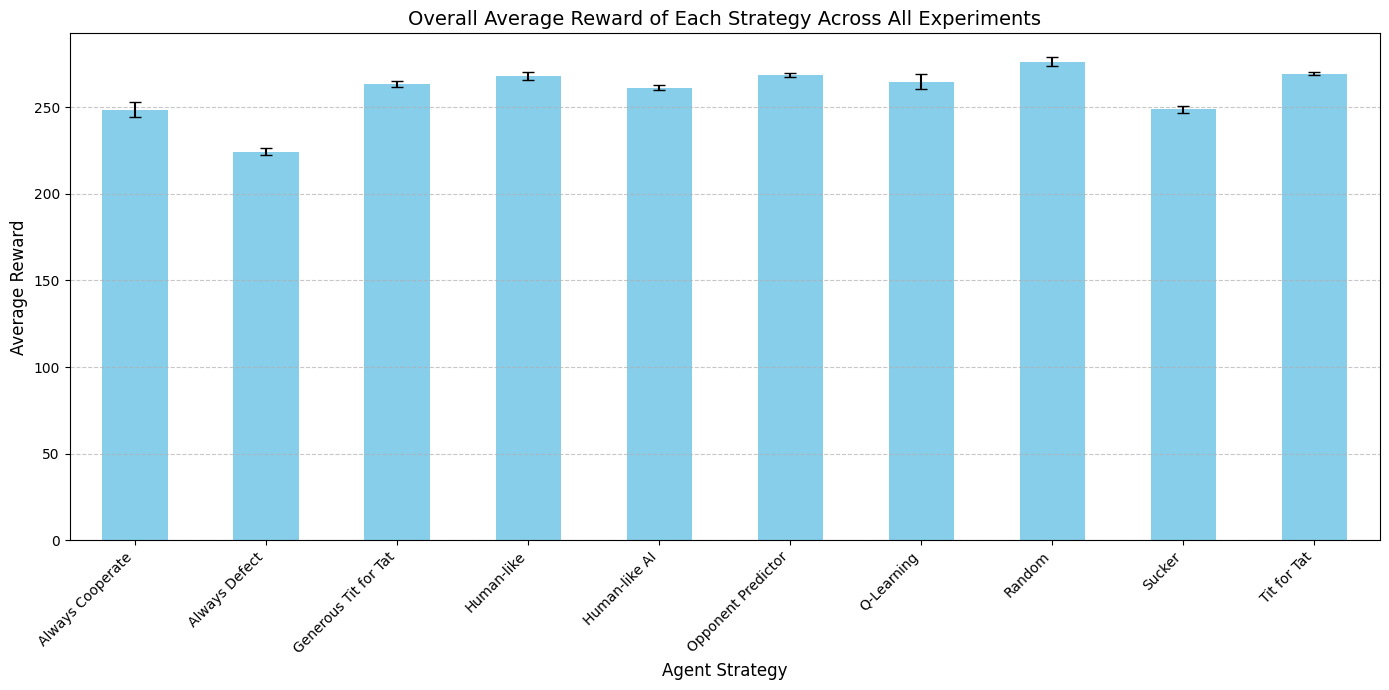

Overall experiment summary plot displayed.
Overall simulation and visualization completed.


In [79]:
# @title
print("Starting the overall simulation and visualization...")

# 1. Run the entire simulation multiple times and save results
run_multiple_experiments_and_save_results(
    num_experiments=num_experiments,
    num_rounds_per_game=num_rounds_per_game,
    num_runs_per_pair=num_runs_per_pair
)

# 2. Visualize the final aggregated results
final_summary_file_path = os.path.join(EXPERIMENT_RESULTS_DIR, 'all_runs_average_rewards.csv')
plot_overall_experiment_summary(final_summary_file_path, EXPERIMENT_RESULTS_DIR)

print("Overall simulation and visualization completed.")

# 결론

이 노트북은 반복 죄수의 딜레마 시뮬레이션을 통해 다양한 AI 및 알고리즘 전략들의 성능과 신뢰성을 비교 분석했습니다. 'Always Defect', 'Tit for Tat', 'Q-Learning', 'Human-like AI' 등 여러 전략들을 정의하고, 이들을 서로 대결시켜 각 전략의 평균 보상과 표준 편차를 평가했습니다. 최종 결과는 `all_runs_average_rewards.csv` 파일과 시각화된 `overall_performance_summary.png` 그래프를 통해 요약되었습니다.

### 주요 발견 사항:

1.  **협력 전략의 중요성**: 'Tit for Tat'과 같이 상호 협력적인 전략들은 장기적으로 높은 평균 보상을 얻는 경향이 있었습니다. 이는 상대방의 협력에 보답하고 배신에 응징함으로써 안정적인 관계를 구축하고 상호 이득을 극대화했기 때문입니다. 'Generous Tit for Tat' 또한 유사한 경향을 보였으나, 때때로 상대방의 배신을 용서함으로써 약간의 변동성을 가졌습니다.

2.  **배신 전략의 한계**: 'Always Defect'와 같은 순수 배신 전략은 단기적으로는 높은 이득을 취할 수 있지만, 장기적으로는 상대방의 협력을 유도하지 못하고 상호 배신으로 이어져 전체적인 보상이 낮아지는 결과를 초래했습니다. 이는 게임 이론에서 예측하는 바와 같이, 반복 게임에서는 순수 배신 전략이 최적이 아님을 보여줍니다.

3.  **학습 및 예측 전략의 잠재력과 위험성**: 'Q-Learning', 'Human-like AI', 'Opponent Predictor'와 같은 학습 및 예측 기반 에이전트들은 환경에 적응하고 최적의 행동을 학습하려는 시도를 보였습니다. 이들은 특정 상황에서 높은 보상을 얻을 잠재력을 가지지만, 시뮬레이션 결과에서 나타나듯이 그들의 평균 보상과 신뢰성(표준 편차로 측정)은 다른 견고한 전략에 비해 **항상 우수하거나 일관적이지 않을 수 있습니다.** 특히, 'Q-Learning'은 학습 초기 단계나 충분한 탐색이 이루어지지 않을 경우 최적의 행동을 찾지 못해 낮은 보상을 받을 수 있으며, 'Opponent Predictor'는 상대방의 패턴이 복잡하거나 변화할 경우 예측 실패로 인해 기대 이하의 성능을 보일 위험이 있습니다. **이는 AI가 자체적으로 '최적'이라고 판단한 선택이 실제로는 실패로 이어질 수 있음을 보여주며, 따라서 AI의 판단을 맹목적으로 신뢰하는 것은 잠재적인 위험을 수반합니다. AI의 성공률은 학습 데이터, 환경의 복잡성, 상대방의 전략 등 다양한 요소에 따라 크게 달라질 수 있으므로, AI의 '선택'이 항상 '성공'을 의미하지 않음을 인지하는 것이 중요합니다.**

4.  **인간적인 전략의 복잡성**: 'Human-like' 및 'HumanLikeAI' 전략은 용서, 보복, 그리고 무작위성을 결합하여 현실적인 행동 패턴을 모방하려 했습니다. 이들은 'Tit for Tat'과 유사하게 안정적인 성능을 보였으나, 때때로 'Forgiveness'나 'Revenge'의 조건에 따라 보상에 편차가 발생하기도 했습니다.

### 결론:

이 시뮬레이션은 반복 죄수의 딜레마에서 각 전략의 특성이 보상 및 협력률에 미치는 영향을 명확하게 보여주었습니다. 특히, 상호성을 기반으로 한 전략들(예: Tit for Tat)이 가장 견고하고 신뢰할 수 있는 성능을 보였으며, 이는 협력이 장기적인 성공에 필수적임을 강조합니다. 반면, 순수 배신 전략은 단기적인 이득에도 불구하고 장기적인 관계에서는 실패할 수 있음을 확인했습니다. **더 나아가, 'Q-Learning', 'Human-like AI', 'Opponent Predictor'와 같은 AI 기반 전략들의 시뮬레이션 결과는 AI가 내린 '최적의 선택'이 항상 최고의 성과를 보장하지 않으며, 상황에 따라서는 예상치 못한 낮은 성공률이나 높은 변동성을 나타낼 수 있음을 시사합니다. 이는 AI의 의사 결정을 무조건적으로 수용하기보다는, 그 성공률과 신뢰성에 대한 비판적인 평가가 필요하다는 중요한 교훈을 제공합니다.** 이러한 통찰은 실제 사회적, 경제적 상호작용에서 의사 결정 과정을 이해하고 모델링하는 데 중요한 시사점을 제공합니다.

## 실험 결과 폴더 초기화 (주의: 모든 결과 파일 삭제)

이 셀을 실행하면 `experiment_results` 폴더 내의 모든 파일과 하위 폴더가 영구적으로 삭제됩니다. 실험 결과를 새로 생성하거나 정리하고 싶을 때만 사용하십시오.

In [91]:
# @title
gonna_deleate = False # @param {"type":"boolean"}
import os
import shutil

# Define the path for the experiment results folder
EXPERIMENT_RESULTS_DIR = 'experiment_results'

# Only proceed with deletion if gonna_deleate is explicitly True
if gonna_deleate:
    if os.path.exists(EXPERIMENT_RESULTS_DIR):
        # Iterate over all items in the directory and remove them
        for item in os.listdir(EXPERIMENT_RESULTS_DIR):
            item_path = os.path.join(EXPERIMENT_RESULTS_DIR, item)
            if os.path.isfile(item_path):
                os.remove(item_path)
                print(f"Removed file: {item_path}")
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
                print(f"Removed directory: {item_path}")
        print(f"All contents of '{EXPERIMENT_RESULTS_DIR}' have been removed.")
    else:
        print(f"Directory '{EXPERIMENT_RESULTS_DIR}' does not exist.")
else:
    print("Deletion was not confirmed. No files were removed.")

Deletion was not confirmed. No files were removed.
